# Sesión 5 — Modelado estructural del pórtico de concreto armado

## Caso `mi_primer_analisis`

Se construye un modelo 2D de un piso y un vano para los dos pórticos resistentes `P1` y `P2`. Cada nodo posee tres GDL $[u_x,u_y,\theta_z]$ y los pórticos se conectan mediante un diafragma axial rígido en el nivel superior.

In [1]:
from pathlib import Path
import json, sys
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)

def buscar_raiz(inicio=None):
    inicio = Path.cwd() if inicio is None else Path(inicio)
    for carpeta in (inicio, *inicio.parents):
        if (carpeta / "temario.md").is_file() and (carpeta / "PUSHOVER_PORTABLE").is_dir():
            return carpeta
    raise FileNotFoundError(
        "No se encontró la raíz del curso. En Colab, clona o monta primero el repositorio."
    )

RAIZ = buscar_raiz()
PORTABLE = RAIZ / "PUSHOVER_PORTABLE"
if str(PORTABLE) in sys.path:
    sys.path.remove(str(PORTABLE))
sys.path.insert(0, str(PORTABLE))

RUTA_MAESTRA = PORTABLE / "casos" / "mi_primer_analisis" / "entrada_maestra.json"
RUTA_GEOMETRIA = PORTABLE / "casos" / "mi_primer_analisis" / "geometria_secciones.json"
CASO_ID = "mi_primer_analisis"

from ejecutar_pushover import cargar_entrada_maestra
from sesion_03.biblioteca_rotulas import leer_contrato_sesion03
from sesion_05.contrato_portable import construir_contrato_sesion05, guardar_contrato_sesion05
from sesion_05.modelo_portico import ensamblar_rigidez_global

entrada, _, _ = cargar_entrada_maestra(RUTA_MAESTRA)
RUTA_C03 = RAIZ / "sesion_03" / "resultados_mi_primer_analisis" / "contrato_sesion03.json"
biblioteca = leer_contrato_sesion03(RUTA_C03)["biblioteca_rotulas"]

## 1. Topología, restricciones y rótulas

Las rótulas se ubican en las caras de los nudos. Los brazos rígidos reducen la longitud flexible a $L_f=L-a_i-a_j$. El diafragma impone compatibilidad horizontal entre ambos pórticos, pero no representa un tercer pórtico resistente.

In [2]:
contrato_s5 = construir_contrato_sesion05(entrada, biblioteca)
nodos = {int(k): np.asarray(v, dtype=float) for k, v in contrato_s5["nodos"].items()}
print("Pórticos:", contrato_s5["geometria"]["ids_porticos"])
print("Nodos:", len(nodos), "| elementos principales:", len(contrato_s5["elementos"]))
print("Enlaces de diafragma:", len(contrato_s5["puntales"]), "| rótulas:", len(contrato_s5["rotulas"]))
print("Nodos de base:", contrato_s5["geometria"]["nodos_base"])
print("Nodos de control:", contrato_s5["geometria"]["nodos_techo"])
assert len(contrato_s5["rotulas"]) == 2 * len(contrato_s5["elementos"])

Pórticos: ['P1', 'P2']
Nodos: 8 | elementos principales: 6
Enlaces de diafragma: 1 | rótulas: 12
Nodos de base: [1, 2, 5, 6]
Nodos de control: [3, 4, 7, 8]


## 2. Visualización de la geometría

La figura muestra la geometría real, sin amplificación de desplazamientos. Las líneas discontinuas son enlaces axiales del diafragma.

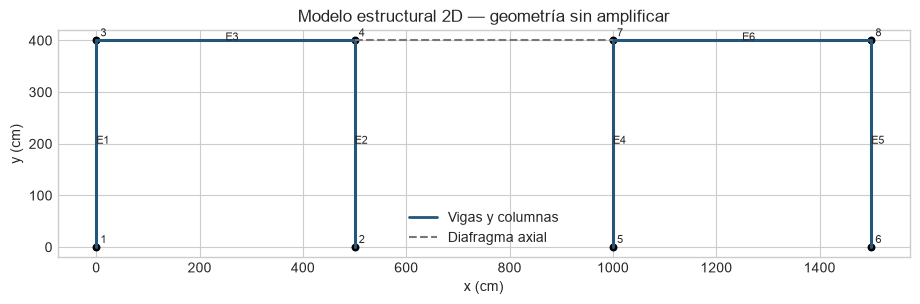

In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
for e in contrato_s5["elementos"]:
    xi, yi = nodos[int(e["i"])]
    xj, yj = nodos[int(e["j"])]
    ax.plot([xi, xj], [yi, yj], color="#24557a", lw=2.2)
    ax.text((xi+xj)/2, (yi+yj)/2, f"E{e['id']}", fontsize=8)
for p in contrato_s5["puntales"]:
    xi, yi = nodos[int(p["i"])]
    xj, yj = nodos[int(p["j"])]
    ax.plot([xi, xj], [yi, yj], "--", color="#777777", lw=1.5)
for nid, (x, y) in nodos.items():
    ax.scatter(x, y, color="black", s=22)
    ax.text(x + 8, y + 8, str(nid), fontsize=8)
ax.plot([], [], color="#24557a", lw=2, label="Vigas y columnas")
ax.plot([], [], "--", color="#777777", label="Diafragma axial")
ax.set_aspect("equal")
ax.set(xlabel="x (cm)", ylabel="y (cm)", title="Modelo estructural 2D — geometría sin amplificar")
ax.legend(); plt.show()

## 3. Brazos rígidos y estabilidad inicial

Se comprueba que todas las longitudes flexibles sean positivas. Después de restringir los GDL de base, la submatriz libre de los elementos principales debe tener rango completo.

In [4]:
print(f"{'E':>3} {'tipo':>8} {'sec':>4} {'L eje':>8} {'ai':>6} {'aj':>6} {'Lf':>8}")
for e in contrato_s5["elementos"]:
    L_e = np.linalg.norm(nodos[int(e["j"])] - nodos[int(e["i"])] )
    Lf = L_e - e["brazo_i_cm"] - e["brazo_j_cm"]
    print(f"{e['id']:3d} {e['tipo']:>8} {e['seccion_id']:>4} {L_e:8.1f} "
          f"{e['brazo_i_cm']:6.1f} {e['brazo_j_cm']:6.1f} {Lf:8.1f}")
    assert Lf > 0

K, _, _ = ensamblar_rigidez_global(nodos, contrato_s5["elementos"])
restr = np.asarray(contrato_s5["restricciones_gdl"], dtype=int)
libres = np.setdiff1d(np.arange(K.shape[0]), restr)
Kff = K[np.ix_(libres, libres)]
print("K global:", K.shape, "| simétrica:", np.allclose(K, K.T))
print("Rango Kff:", np.linalg.matrix_rank(Kff), "de", len(libres))
assert np.allclose(K, K.T)
assert np.linalg.matrix_rank(Kff) == len(libres)

  E     tipo  sec    L eje     ai     aj       Lf
  1  columna   C1    400.0    0.0   15.0    385.0
  2  columna   C1    400.0    0.0   15.0    385.0
  3     viga   V1    500.0   15.0   15.0    470.0
  4  columna   C1    400.0    0.0   15.0    385.0
  5  columna   C1    400.0    0.0   15.0    385.0
  6     viga   V1    500.0   15.0   15.0    470.0
K global: (24, 24) | simétrica: True
Rango Kff: 12 de 12


## 4. Exportación del contrato estructural 3.4

In [5]:
SALIDA = RAIZ / "sesion_05" / "resultados_mi_primer_analisis"
RUTA_C05 = SALIDA / "contrato_sesion05.json"
guardar_contrato_sesion05(contrato_s5, RUTA_C05)
releido = json.loads(RUTA_C05.read_text(encoding="utf-8"))
assert releido["schema_version"] == "3.4"
assert releido["caso_id"] == CASO_ID
print("Contrato guardado:", RUTA_C05.relative_to(RAIZ))

Contrato guardado: sesion_05\resultados_mi_primer_analisis\contrato_sesion05.json


## 5. Cierre

El contrato contiene topología, restricciones, diafragma, brazos rígidos y leyes iniciales a $P=0$. En la sesión 6 se resolverá primero la gravedad y se recalibrarán las columnas para la carga axial real.